# **Redes Generativas Adversarias Convolucionales Profundas**

![Imgur](https://i.imgur.com/ya1gA5H.png)

In [ ]:
import os, random, math, glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("checkpoints", exist_ok=True)

Device: cuda


In [ ]:
batch_size = 128
epochs = 20
lr = 2e-4
beta1, beta2 = 0.5, 0.999

z_dim = 100
n_classes = 10
y_emb_dim = 20

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

print("Train size:", len(train_ds))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 191kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.54MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]

Train size: 60000


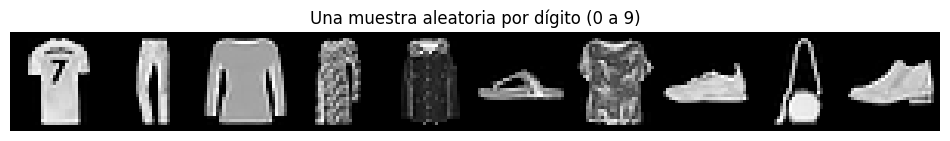

In [ ]:
idx_by_label = {k: [] for k in range(10)}
for i in range(len(train_ds)):
    _, y = train_ds[i]
    if len(idx_by_label[y]) < 200:
        idx_by_label[y].append(i)
    if all(len(idx_by_label[k]) >= 200 for k in range(10)):
        break

samples = []
for k in range(10):
    i = random.choice(idx_by_label[k])
    x, _ = train_ds[i]
    samples.append(x)

samples = torch.stack(samples, dim=0)
grid = make_grid(samples, nrow=10, normalize=True, value_range=(-1, 1))

fig = plt.figure(figsize=(12, 2))
ax = fig.subplots(1, 1)
ax.axis("off")
ax.set_title("Una muestra aleatoria por prenda")
ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

In [ ]:
def onehot_map(y, h, w, n_classes=10, device=None):
    b = y.size(0)
    oh = torch.zeros(b, n_classes, device=device)
    oh.scatter_(1, y.view(-1, 1), 1.0)
    return oh.view(b, n_classes, 1, 1).expand(b, n_classes, h, w)

class Generator(nn.Module):
    def __init__(self, z_dim=100, y_emb_dim=20, n_classes=10, base=64):
        super().__init__()
        self.emb = nn.Embedding(n_classes, y_emb_dim)
        in_ch = z_dim + y_emb_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_ch, base*4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(base*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*4, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base*2, base, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base),
            nn.ReLU(True),

            nn.Conv2d(base, 1, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, y):
        yv = self.emb(y).view(y.size(0), -1, 1, 1)
        x = torch.cat([z, yv], dim=1)
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, n_classes=10, base=64):
        super().__init__()
        in_ch = 1 + n_classes
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 3, 2, 1, bias=False),
            nn.BatchNorm2d(base*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x, y):
        ymap = onehot_map(y, x.size(2), x.size(3), n_classes=n_classes, device=x.device)
        inp = torch.cat([x, ymap], dim=1)
        return self.net(inp).view(-1)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d, nn.Embedding)):
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

G = Generator(z_dim=z_dim, y_emb_dim=y_emb_dim, n_classes=n_classes, base=64).to(device)
D = Discriminator(n_classes=n_classes, base=64).to(device)
G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
optD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

print("Params G:", sum(p.numel() for p in G.parameters()))
print("Params D:", sum(p.numel() for p in D.parameters()))


Params G: 2162312
Params D: 442112


In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(8, z_dim, 1, 1, device=device)
    y = torch.randint(0, 10, (8,), device=device)
    fake = G(z, y)
print("Fake shape:", fake.shape)

D.eval()
with torch.no_grad():
    out = D(fake, y)
print("D(fake) shape:", out.shape)

G.train()
D.train()


Fake shape: torch.Size([8, 1, 28, 28])
D(fake) shape: torch.Size([8])


Discriminator(
  (net): Sequential(
    (0): Conv2d(11, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)

In [ ]:
lossD_hist = []
lossG_hist = []

for epoch in range(1, epochs + 1):
    lossD_acc = 0.0
    lossG_acc = 0.0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
    for real, y in pbar:
        real = real.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        b = real.size(0)

        z = torch.randn(b, z_dim, 1, 1, device=device)
        fake = G(z, y)

        D_real = D(real, y)
        D_fake = D(fake.detach(), y)

        y_real = torch.ones_like(D_real)
        y_fake = torch.zeros_like(D_fake)

        lossD = criterion(D_real, y_real) + criterion(D_fake, y_fake)

        optD.zero_grad(set_to_none=True)
        lossD.backward()
        optD.step()

        z2 = torch.randn(b, z_dim, 1, 1, device=device)
        fake2 = G(z2, y)
        D_fake2 = D(fake2, y)

        y_gen = torch.ones_like(D_fake2)
        lossG = criterion(D_fake2, y_gen)

        optG.zero_grad(set_to_none=True)
        lossG.backward()
        optG.step()

        lossD_acc += float(lossD.item())
        lossG_acc += float(lossG.item())
        n_batches += 1

        pbar.set_postfix(lossD=float(lossD.item()), lossG=float(lossG.item()))

    lossD_epoch = lossD_acc / max(1, n_batches)
    lossG_epoch = lossG_acc / max(1, n_batches)

    lossD_hist.append(lossD_epoch)
    lossG_hist.append(lossG_epoch)

    print(f"Epoch {epoch:02d} | lossD: {lossD_epoch:.4f} | lossG: {lossG_epoch:.4f}")

    torch.save(
        {"G": G.state_dict(), "D": D.state_dict(), "epoch": epoch},
        f"checkpoints/cgan_mnist_epoch_{epoch:03d}.pt"
    )

print("Listo. Checkpoints en checkpoints/.")

Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | lossD: 0.6763 | lossG: 1.8624


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | lossD: 1.0228 | lossG: 1.2886


Epoch 3/20:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 18 | lossD: 1.2530 | lossG: 0.8853


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 19 | lossD: 1.2527 | lossG: 0.8897


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 20 | lossD: 1.2461 | lossG: 0.8942
Listo. Checkpoints en checkpoints/.


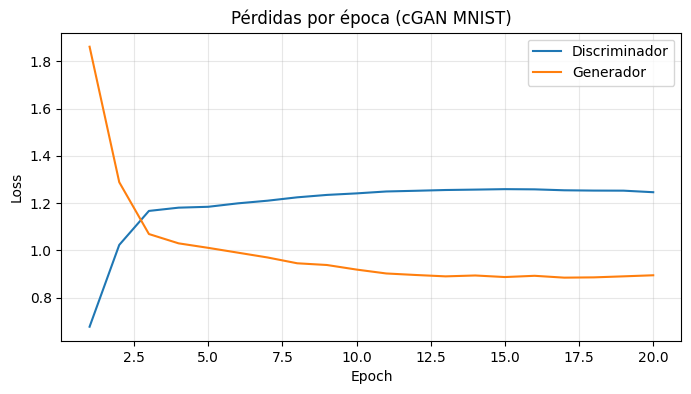

In [ ]:
fig = plt.figure(figsize=(8, 4))
ax = fig.subplots(1, 1)
ax.plot(range(1, len(lossD_hist) + 1), lossD_hist, label="Discriminador")
ax.plot(range(1, len(lossG_hist) + 1), lossG_hist, label="Generador")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title("Pérdidas por época (cGAN Fashion MNIST)")
plt.show()


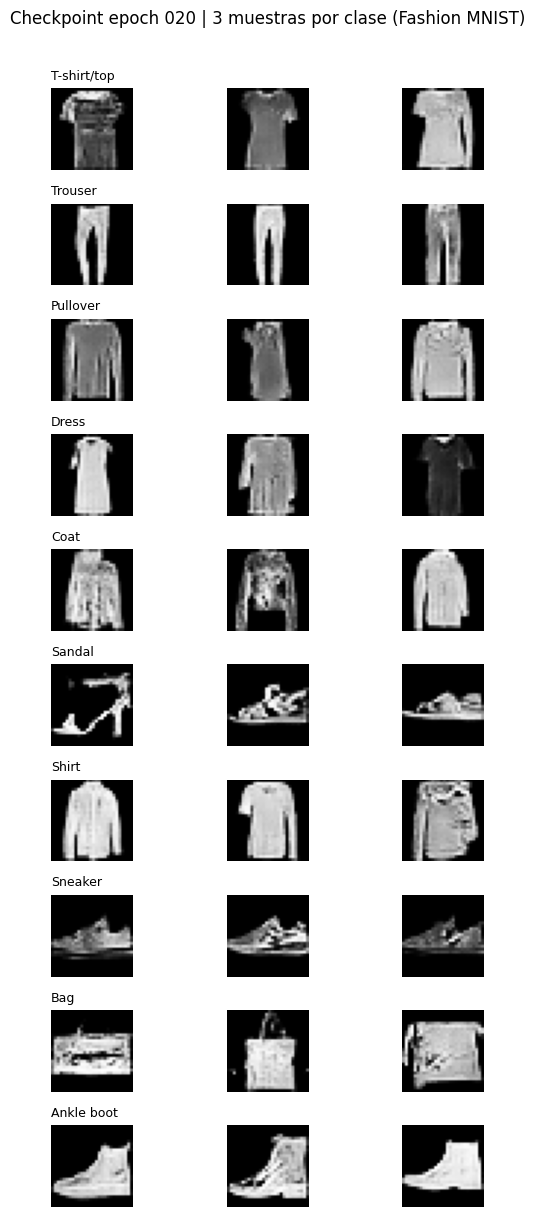

In [ ]:
def load_checkpoint(epoch_num: int):
    path = f"checkpoints/cgan_mnist_epoch_{epoch_num:03d}.pt"
    if not os.path.exists(path):
        raise FileNotFoundError(f"No existe el checkpoint: {path}")
    state = torch.load(path, map_location=device)
    G.load_state_dict(state["G"])
    D.load_state_dict(state["D"])
    G.to(device).eval()
    D.to(device).eval()
    return state.get("epoch", epoch_num)


FASHION_LABELS = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def show_3_per_class_from_epoch(epoch_num: int, z_dim=100):
    ep = load_checkpoint(epoch_num)

    n_per = 3
    total = 10 * n_per

    z = torch.randn(total, z_dim, 1, 1, device=device)
    y = torch.tensor(
        [d for d in range(10) for _ in range(n_per)],
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():
        x = G(z, y)

    x = (x * 0.5 + 0.5).clamp(0, 1).cpu()

    fig = plt.figure(figsize=(6, 12))
    axes = fig.subplots(10, 3)

    k = 0
    for r in range(10):
        for c in range(3):
            ax = axes[r, c]
            ax.axis("off")
            ax.imshow(x[k, 0].numpy(), cmap="gray", vmin=0, vmax=1)
            if c == 0:
                ax.set_title(FASHION_LABELS[r], loc="left", fontsize=9)
            k += 1

    fig.suptitle(
        f"Checkpoint epoch {ep:03d} | 3 muestras por clase (Fashion MNIST)",
        y=1.01
    )
    fig.tight_layout()
    plt.show()

show_3_per_class_from_epoch(20)


Clases disponibles:
- T-shirt/top
- Trouser
- Pullover
- Dress
- Coat
- Sandal
- Shirt
- Sneaker
- Bag
- Ankle boot
Ingresa el nombre exacto de la prenda: Pullover


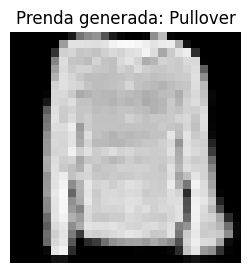

In [ ]:
FASHION_LABELS = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

FASHION_TO_IDX = {name.lower(): i for i, name in enumerate(FASHION_LABELS)}

def generate_fashion_from_input():
    print("Clases disponibles:")
    for name in FASHION_LABELS:
        print(f"- {name}")

    cls_name = input("Ingresa el nombre exacto de la prenda: ").strip().lower()

    if cls_name not in FASHION_TO_IDX:
        raise ValueError("Nombre de prenda inválido")

    cls = FASHION_TO_IDX[cls_name]

    G.eval()

    z = torch.randn(1, z_dim, 1, 1, device=device)
    y = torch.tensor([cls], dtype=torch.long, device=device)

    with torch.no_grad():
        x = G(z, y)

    x = (x * 0.5 + 0.5).clamp(0, 1).cpu()

    fig = plt.figure(figsize=(3, 3))
    ax = fig.subplots(1, 1)
    ax.axis("off")
    ax.set_title(f"Prenda generada: {FASHION_LABELS[cls]}")
    ax.imshow(x[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    plt.show()

generate_fashion_from_input()
